In [1]:
import kagglehub

path = kagglehub.dataset_download("garymk/kitti-3d-object-detection-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/garymk/kitti-3d-object-detection-dataset


In [2]:
from pathlib import Path
import kagglehub

path = Path(kagglehub.dataset_download("garymk/kitti-3d-object-detection-dataset"))
ROOT = next(path.rglob("label_2")).parent 

print("Training data:", ROOT)
for sub in ["velodyne", "label_2", "calib", "image_2"]:
    print(f"{sub:10s}", len(list((ROOT / sub).iterdir())), "files")

Training data: /kaggle/input/datasets/garymk/kitti-3d-object-detection-dataset/training
velodyne   7481 files
label_2    7481 files
calib      7481 files
image_2    7481 files


In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def load_scan(frame: str) -> np.ndarray:
    """(N, 4) array: x forward, y left, z up, intensity."""
    return np.fromfile(ROOT / "velodyne" / f"{frame}.bin", dtype=np.float32).reshape(-1, 4)

points = load_scan("000010")
print(points.shape)
print("x range:", points[:, 0].min().round(1), "to", points[:, 0].max().round(1))
print("z range:", points[:, 2].min().round(1), "to", points[:, 2].max().round(1))

(115875, 4)
x range: -60.4 to 78.4
z range: -14.1 to 2.9


In [5]:
z = points[:, 2]
print("1% lowest z:", np.percentile(z, 1).round(2))
print("points below -3 m:", (z < -3).sum())

1% lowest z: -1.97
points below -3 m: 16


In [6]:
def load_cam_to_velo(frame: str) -> np.ndarray:
    """4x4 transform from rectified camera coordinates to LiDAR coordinates."""
    calib = {}
    for line in (ROOT / "calib" / f"{frame}.txt").read_text().splitlines():
        if ":" in line:
            key, values = line.split(":", 1)
            calib[key] = np.array(values.split(), dtype=np.float64)
    r0 = np.eye(4)
    r0[:3, :3] = calib["R0_rect"].reshape(3, 3)
    tr = np.eye(4)
    tr[:3, :] = calib["Tr_velo_to_cam"].reshape(3, 4)
    return np.linalg.inv(r0 @ tr)

cam_to_velo = load_cam_to_velo("000010")
print(cam_to_velo.round(3))

[[ 0.     0.01   1.     0.273]
 [-1.     0.011  0.    -0.002]
 [-0.011 -1.     0.01  -0.072]
 [ 0.     0.     0.     1.   ]]


In [7]:
def load_labels(frame: str, cam_to_velo: np.ndarray) -> list[dict]:
    """Objects with centre, size (l, w, h) and yaw in LiDAR coordinates."""
    objects = []
    for line in (ROOT / "label_2" / f"{frame}.txt").read_text().splitlines():
        f = line.split()
        if f[0] == "DontCare":
            continue
        h, w, l, x, y, z, ry = map(float, f[8:15])
        centre = cam_to_velo @ np.array([x, y - h / 2, z, 1.0])  # camera y points down
        objects.append({"cls": f[0], "centre": centre[:3], "size": (l, w, h), "yaw": -ry - np.pi / 2})
    return objects

objects = load_labels("000010", cam_to_velo)
for o in objects:
    print(f"{o['cls']:12s} centre={o['centre'].round(1)}  size={np.round(o['size'], 1)}")

Car          centre=[ 5.5 -4.4 -0.9]  size=[3.4 1.6 1.6]
Car          centre=[12.1  2.4 -0.9]  size=[4.  1.7 1.4]
Pedestrian   centre=[23.8 -8.3 -0.5]  size=[1.1 0.7 2. ]
Car          centre=[16.8 -5.8 -0.8]  size=[3.2 1.6 1.5]
Car          centre=[22.3 -6.9 -0.8]  size=[4.1 1.7 1.4]
Car          centre=[23.9  0.4 -0.8]  size=[3.8 1.7 1.5]
Car          centre=[29.4 -0.6 -0.8]  size=[3.4 1.5 1.5]
Car          centre=[28.8 -7.9 -0.8]  size=[4.4 1.6 1.5]
Car          centre=[43.1 -4.5 -0.7]  size=[3.5 1.4 1.6]


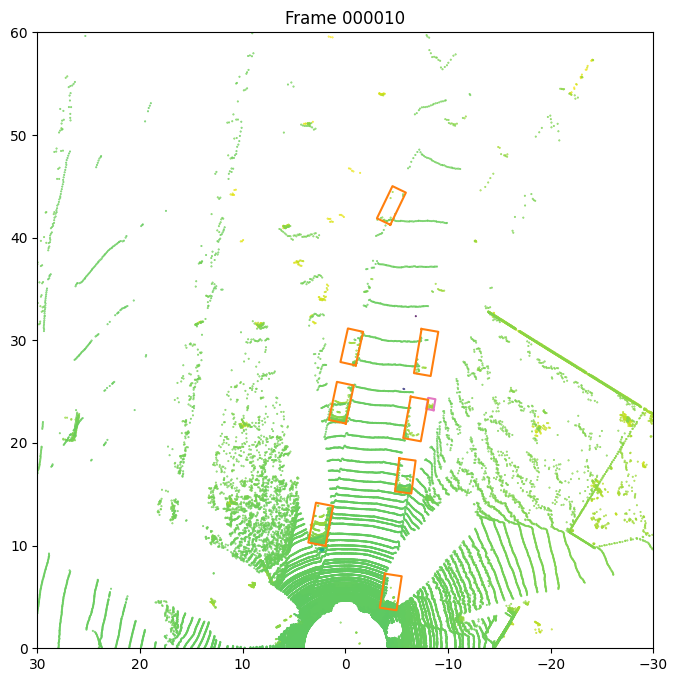

In [8]:
COLOURS = {"Car": "tab:orange", "Van": "tab:orange", "Pedestrian": "tab:pink", "Cyclist": "tab:green"}

def bev_corners(obj: dict) -> np.ndarray:
    l, w, _ = obj["size"]
    c, s = np.cos(obj["yaw"]), np.sin(obj["yaw"])
    local = np.array([[l/2, w/2], [l/2, -w/2], [-l/2, -w/2], [-l/2, w/2]])
    return local @ np.array([[c, -s], [s, c]]).T + obj["centre"][:2]

def plot_bev(frame: str, ax=None):
    points = load_scan(frame)
    objects = load_labels(frame, load_cam_to_velo(frame))
    keep = (points[:, 0] > 0) & (points[:, 0] < 60) & (np.abs(points[:, 1]) < 30)
    ax = ax or plt.subplots(figsize=(8, 8))[1]
    ax.scatter(points[keep, 1], points[keep, 0], s=0.2, c=points[keep, 2], cmap="viridis")
    for obj in objects:
        poly = np.vstack([bev_corners(obj), bev_corners(obj)[:1]])
        ax.plot(poly[:, 1], poly[:, 0], color=COLOURS.get(obj["cls"], "tab:red"), lw=1.5)
    ax.set(xlim=(30, -30), ylim=(0, 60), aspect="equal", title=f"Frame {frame}")
    return ax

plot_bev("000010")
plt.show()

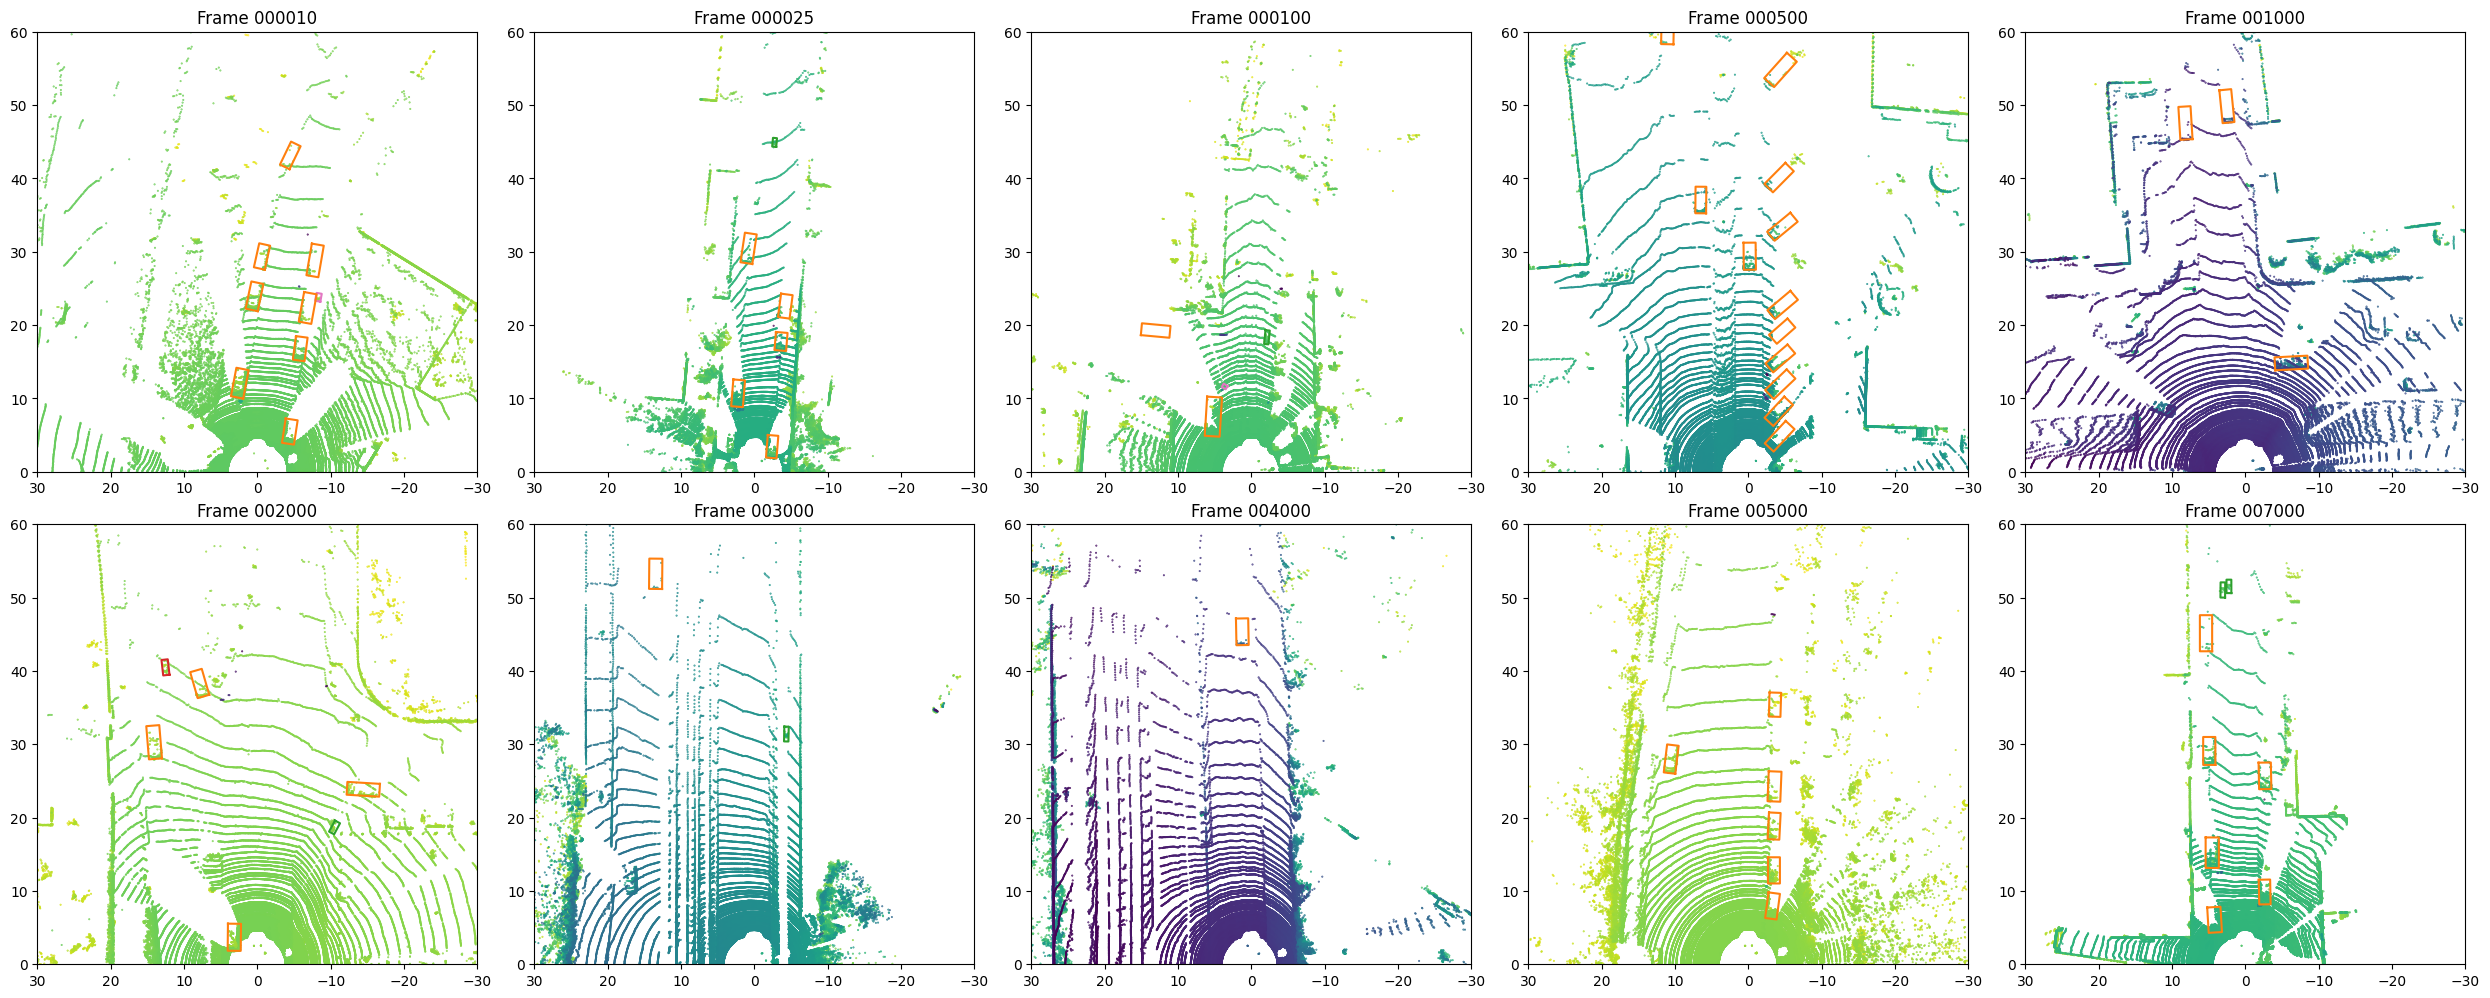

In [9]:
frames = ["000010", "000025", "000100", "000500", "001000",
          "002000", "003000", "004000", "005000", "007000"]
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
for frame, ax in zip(frames, axes.flat):
    plot_bev(frame, ax)
plt.tight_layout()
plt.show()

In [10]:
def points_in_box(points: np.ndarray, box: dict) -> np.ndarray:
    """Boolean mask of points inside a 3D box."""
    shifted = points[:, :3] - box["centre"]
    c, s = np.cos(-box["yaw"]), np.sin(-box["yaw"])
    local_x = shifted[:, 0] * c - shifted[:, 1] * s
    local_y = shifted[:, 0] * s + shifted[:, 1] * c
    l, w, h = box["size"]
    return (np.abs(local_x) <= l/2) & (np.abs(local_y) <= w/2) & (np.abs(shifted[:, 2]) <= h/2)

points = load_scan("000010")
for obj in load_labels("000010", load_cam_to_velo("000010")):
    n = points_in_box(points, obj).sum()
    print(f"{obj['cls']:12s} {np.linalg.norm(obj['centre'][:2]):5.1f} m away  →  {n} points")

Car            7.0 m away  →  1628 points
Car           12.3 m away  →  1012 points
Pedestrian    25.2 m away  →  23 points
Car           17.8 m away  →  340 points
Car           23.4 m away  →  48 points
Car           23.9 m away  →  245 points
Car           29.4 m away  →  53 points
Car           29.9 m away  →  33 points
Car           43.4 m away  →  20 points


In [11]:
import pandas as pd

def label_flags(frame: str) -> list[tuple]:
    """(truncated, occluded) per object, same order as load_labels."""
    flags = []
    for line in (ROOT / "label_2" / f"{frame}.txt").read_text().splitlines():
        f = line.split()
        if f[0] != "DontCare":
            flags.append((float(f[1]), int(f[2])))
    return flags

def frame_stats(frame: str) -> list[dict]:
    points = load_scan(frame)
    points = points[points[:, 0] > -1]  # labels only exist in front of the car
    rows = []
    for obj, (trunc, occ) in zip(load_labels(frame, load_cam_to_velo(frame)), label_flags(frame)):
        inside = points[points_in_box(points, obj)]
        bottom = obj["centre"][2] - obj["size"][2] / 2
        rows.append({
            "frame": frame, "cls": obj["cls"],
            "dist": np.linalg.norm(obj["centre"][:2]),
            "angle": np.degrees(np.arctan2(obj["centre"][1], obj["centre"][0])),
            "n_points": len(inside),
            "l": obj["size"][0], "w": obj["size"][1], "h": obj["size"][2],
            "bottom_z": bottom,
            "gap": inside[:, 2].min() - bottom if len(inside) else np.nan,
            "truncated": trunc, "occluded": occ,
        })
    return rows

In [12]:
n_frames = len(list((ROOT / "label_2").iterdir()))
sample = [f"{i:06d}" for i in np.linspace(0, n_frames - 1, 500).astype(int)]

df = pd.DataFrame([row for frame in sample for row in frame_stats(frame)])
print(len(df), "objects from", len(sample), "frames")
df.head()

2737 objects from 500 frames


,frame,cls,dist,angle,n_points,l,w,h,bottom_z,gap,truncated,occluded
0,000000,Pedestrian,8.933850,-12.069559,377,1.20,0.48,1.89,-1.599790,0.000790,0.0,0
1,000014,Car,60.144932,-2.433576,16,4.39,1.68,1.44,-1.194231,0.154231,0.0,0
2,000029,Misc,23.725865,7.362067,206,2.07,1.21,1.61,-1.497187,0.016187,0.0,0
3,000029,Car,41.953282,-4.712167,61,3.30,1.69,1.64,-1.454687,0.012687,0.0,0
4,000044,Car,6.405420,30.792909,3149,3.67,1.62,1.44,-1.713076,0.000076,0.7,0


In [13]:
counts = df["cls"].value_counts()
print(counts)
print("\nper frame:", round(len(df) / len(sample), 1), "objects on average")

cls
Car               2007
Pedestrian         247
Van                177
Cyclist            113
Truck               68
Misc                66
Tram                43
Person_sitting      16
Name: count, dtype: int64

per frame: 5.5 objects on average


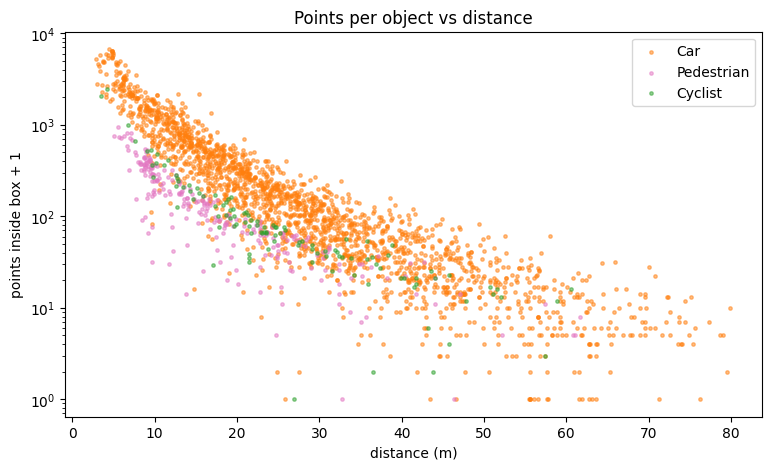

In [14]:
main = ["Car", "Pedestrian", "Cyclist"]
fig, ax = plt.subplots(figsize=(9, 5))
for cls in main:
    d = df[df["cls"] == cls]
    ax.scatter(d["dist"], d["n_points"] + 1, s=6, alpha=0.5, label=cls, color=COLOURS[cls])
ax.set(yscale="log", xlabel="distance (m)", ylabel="points inside box + 1",
       title="Points per object vs distance")
ax.legend()
plt.show()

In [15]:
bins = [0, 20, 40, 80]
df["range"] = pd.cut(df["dist"], bins, labels=["near <20", "mid 20-40", "far >40"])
df[df["cls"].isin(main)].groupby(["cls", "range"], observed=True)["n_points"].describe()[["count", "50%", "min", "max"]]

count    50%   min     max
cls        range                                
Car        near <20   665.0  669.0  15.0  6701.0
           mid 20-40  835.0   90.0   0.0   707.0
           far >40    507.0   15.0   0.0   119.0
Cyclist    near <20    40.0  184.0  28.0  2480.0
           mid 20-40   55.0   48.0   0.0   109.0
           far >40     18.0   15.0   1.0    24.0
Pedestrian near <20   158.0  181.5  13.0   937.0
           mid 20-40   76.0   40.5   0.0    92.0
           far >40     13.0   10.0   0.0    31.0

In [16]:
# objects that are almost empty - these break the feature step later
for k in [0, 5, 10]:
    print(f"<= {k:2d} points: {(df['n_points'] <= k).sum():4d}  ({(df['n_points'] <= k).mean():.1%})")

print("\nempty boxes by occlusion level (0 visible ... 3 unknown):")
print(df[df["n_points"] == 0]["occluded"].value_counts().sort_index())

<=  0 points:   27  (1.0%)
<=  5 points:  137  (5.0%)
<= 10 points:  229  (8.4%)

empty boxes by occlusion level (0 visible ... 3 unknown):
occluded
0     2
1     6
2    19
Name: count, dtype: int64


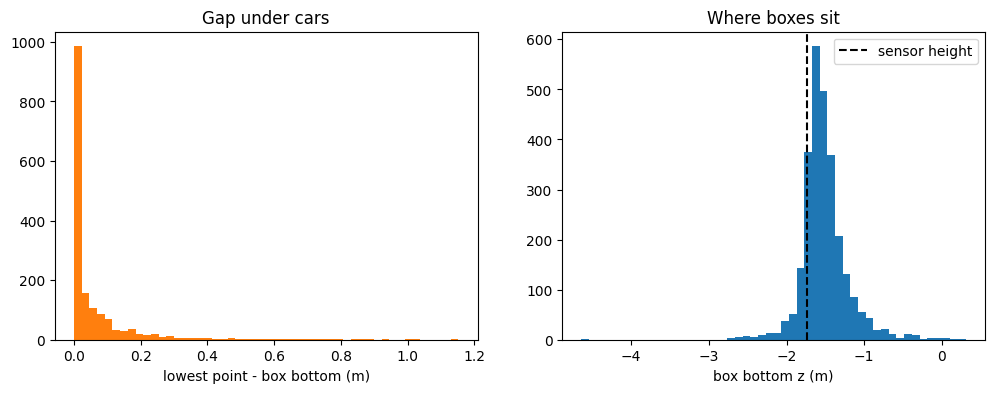

median gap: 0.011 m


In [18]:
# height check: lowest point inside a box should be close to the box bottom
cars = df[(df["cls"] == "Car") & (df["n_points"] >= 20)]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(cars["gap"], bins=50, color="tab:orange")
axes[0].set(xlabel="lowest point - box bottom (m)", title="Gap under cars")
axes[1].hist(df["bottom_z"], bins=50, color="tab:blue")
axes[1].axvline(-1.73, color="k", ls="--", label="sensor height")
axes[1].set(xlabel="box bottom z (m)", title="Where boxes sit")
axes[1].legend()
plt.show()

print("median gap:", round(cars["gap"].median(), 3), "m")

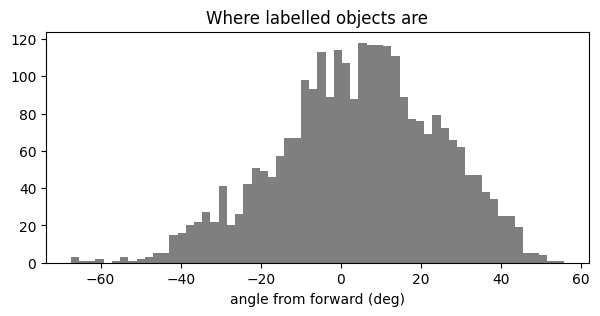

outside +-50 deg: 19


In [19]:
# labels should only be inside the front camera view (about +-45 deg)
plt.figure(figsize=(7, 3))
plt.hist(df["angle"], bins=60, color="tab:gray")
plt.xlabel("angle from forward (deg)")
plt.title("Where labelled objects are")
plt.show()
print("outside +-50 deg:", (df["angle"].abs() > 50).sum())

In [20]:
# box sizes per class - quick sanity check of l, w, h
df[df["cls"].isin(main)].groupby("cls")[["l", "w", "h"]].agg(["mean", "std"]).round(2)

l           w           h      
            mean   std  mean   std  mean   std
cls                                           
Car         3.89  0.43  1.63  0.10  1.52  0.14
Cyclist     1.76  0.17  0.59  0.13  1.74  0.09
Pedestrian  0.84  0.24  0.68  0.16  1.77  0.12

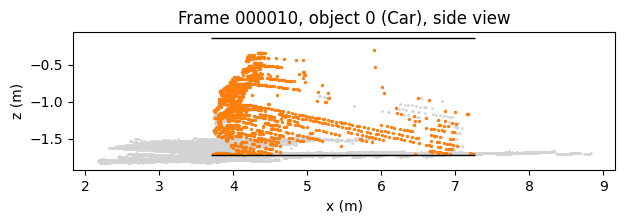

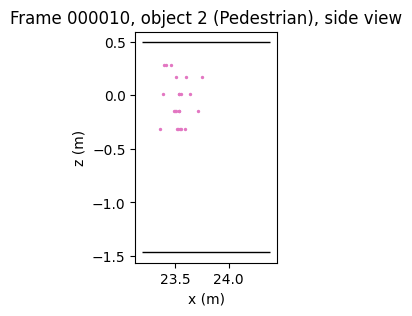

In [21]:
def plot_side(frame: str, index: int):
    """Side view (x-z) of one object with its box, to check the height."""
    points = load_scan(frame)
    obj = load_labels(frame, load_cam_to_velo(frame))[index]
    l, w, h = obj["size"]
    near = np.linalg.norm(points[:, :2] - obj["centre"][:2], axis=1) < max(l, w)
    inside = points_in_box(points, obj)
    plt.figure(figsize=(7, 3))
    plt.scatter(points[near & ~inside, 0], points[near & ~inside, 2], s=1, c="lightgray")
    plt.scatter(points[inside, 0], points[inside, 2], s=2, c=COLOURS.get(obj["cls"], "tab:red"))
    corners = np.vstack([bev_corners(obj), bev_corners(obj)[:1]])
    zb, zt = obj["centre"][2] - h / 2, obj["centre"][2] + h / 2
    plt.hlines([zb, zt], corners[:, 0].min(), corners[:, 0].max(), colors="k", lw=1)
    plt.gca().set_aspect("equal")
    plt.title(f"Frame {frame}, object {index} ({obj['cls']}), side view")
    plt.xlabel("x (m)"); plt.ylabel("z (m)")
    plt.show()

plot_side("000010", 0)
plot_side("000010", 2)